# Inventory Management
### EOQ · Reorder Point · Safety Stock

> **Where this fits in the project pipeline:**  
> `EDA → Feature Engineering → XGBoost Forecasting → **Inventory Decisions (this notebook)**`
>
> The XGBoost model (MAPE ≈ 12.4%) gives us **predicted daily demand per item per store**.  
> This notebook converts those forecasts into three actionable inventory decisions:
> - **EOQ** — How much to order at once?
> - **ROP** — When to place the next order?
> - **Safety Stock** — How much buffer to keep against demand uncertainty?

---
## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 4)})

---
## 1. Load Forecasted Demand

We load our **XGBoost predictions** (the best model, MAPE ≈ 12.4%) alongside actual sales.  
The `val_df` below represents year **2017** — the period we use for inventory planning.

In [2]:
import joblib, sys

featured_df = pd.read_csv("../data/processed/featured_data.csv", parse_dates=["date"])
val_df   = featured_df[featured_df["date"] >= "2017-01-01"].copy()
y_pred = joblib.load("../models/xgb_preds.joblib")
val_df["y_pred"] = y_pred
val_df["y_pred"] = val_df["y_pred"].clip(lower=0)

print(f'Shape: {val_df.shape}  |  Date range: {val_df.date.min().date()} → {val_df.date.max().date()}')
val_df[['date','store','item','sales','y_pred']].head()

Shape: (182500, 20)  |  Date range: 2017-01-01 → 2017-12-31


,date,store,item,sales,y_pred
1433,2017-01-01,1,1,19,19.526623
1434,2017-01-02,1,1,15,13.029686
1435,2017-01-03,1,1,10,15.177684
1436,2017-01-04,1,1,16,15.277492
1437,2017-01-05,1,1,14,15.700456


---
## 2. Aggregate to Item-Level Annual Demand

Inventory formulas work on **annual demand (D)** and **demand variability (σ_d)**.  
We aggregate across all 10 stores per item (total demand your supply chain must serve).

In [3]:
val_df.head()

,date,store,item,sales,year,month,week,day,dayofweek,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,store_avg_sales,item_avg_sales,y_pred
1433,2017-01-01,1,1,19,2017,1,52,1,6,1,14.0,20.0,22.0,24.0,17.285714,17.428571,16.178571,47.268379,21.981599,19.526623
1434,2017-01-02,1,1,15,2017,1,1,2,0,0,19.0,16.0,17.0,13.0,17.142857,17.214286,16.000000,47.268379,21.981599,13.029686
1435,2017-01-03,1,1,10,2017,1,1,3,1,0,15.0,10.0,18.0,10.0,17.000000,17.071429,16.071429,47.268379,21.981599,15.177684
1436,2017-01-04,1,1,16,2017,1,1,4,2,0,10.0,16.0,12.0,17.0,17.000000,16.500000,16.071429,47.268379,21.981599,15.277492
1437,2017-01-05,1,1,14,2017,1,1,5,3,0,16.0,21.0,20.0,15.0,17.000000,16.785714,16.035714,47.268379,21.981599,15.700456


In [4]:
# Daily demand per item (sum across all stores)
daily_item = (
    val_df
    .groupby(['date', 'item'])[['sales', 'y_pred']]
    .sum()
    .reset_index()
)

# Item-level summary stats
item_stats = daily_item.groupby('item').agg(
    annual_actual_demand   = ('sales',  'sum'),
    annual_forecast_demand = ('y_pred', 'sum'),
    avg_daily_demand       = ('y_pred', 'mean'),
    std_daily_demand       = ('y_pred', 'std'),    # demand variability
    days_of_data           = ('y_pred', 'count')
).reset_index()

item_stats['cv'] = item_stats['std_daily_demand'] / item_stats['avg_daily_demand']  # coefficient of variation

print(f'Items: {len(item_stats)}  |  Stores aggregated: 10')
item_stats.head(10).round(2)

Items: 50  |  Stores aggregated: 10


,item,annual_actual_demand,annual_forecast_demand,avg_daily_demand,std_daily_demand,days_of_data,cv
0,1,90153,89536.687500,245.309998,53.009998,365,0.22
1,2,240421,238906.515625,654.539978,143.660004,365,0.22
2,3,150802,149718.687500,410.190002,89.919998,365,0.22
3,4,89783,89231.250000,244.470001,53.540001,365,0.22
4,5,75807,75670.296875,207.320007,44.919998,365,0.22
5,6,239989,238055.421875,652.210022,141.380005,365,0.22
6,7,240039,238143.125000,652.450012,142.539993,365,0.22
7,8,316911,313155.843750,857.960022,188.539993,365,0.22
8,9,210697,209693.578125,574.500000,124.449997,365,0.22
9,10,301861,299301.937500,820.010010,178.830002,365,0.22


---
## 3. Business Parameters

These are **cost and operational inputs** that come from business/supply chain team.  
`We have taken the most common values for them`

In [5]:
# ── Ordering Cost (S): fixed cost per purchase order placed ─────────────────
# Examples: admin time, freight, supplier handling fee
ORDERING_COST = 50.0          # $ per order

# ── Holding Cost Rate (h): annual cost to hold 1 unit for 1 year ─────────────
# Typically 20–30% of unit value. Here we use a flat $2 / unit / year.
HOLDING_COST_PER_UNIT = 2.0   # $ / unit / year

# ── Lead Time (L): days between placing an order and receiving it ─────────────
LEAD_TIME_DAYS = 7            # days (1 week)

# ── Service Level (z): desired probability of NOT stocking out ───────────────
# 95% → z = 1.645 | 97.5% → z = 1.96 | 99% → z = 2.326
SERVICE_LEVEL = 0.95
Z_SCORE = 1.645               # standard normal z for 95% service level

print('We Have Set the Business parameters')
print(f'  Ordering cost (S)      : ${ORDERING_COST}')
print(f'  Holding cost (h)       : ${HOLDING_COST_PER_UNIT}/unit/year')
print(f'  Lead time (L)          : {LEAD_TIME_DAYS} days')
print(f'  Service level          : {SERVICE_LEVEL*100:.0f}%  →  z = {Z_SCORE}')

We Have Set the Business parameters
  Ordering cost (S)      : $50.0
  Holding cost (h)       : $2.0/unit/year
  Lead time (L)          : 7 days
  Service level          : 95%  →  z = 1.645


---
## 4. Economic Order Quantity (EOQ)

### The Formula

$$
\text{EOQ} = \sqrt{\dfrac{2 \cdot D \cdot S}{h}}
$$

#### D  = Annual demand (units/year) -> XGBoost forecast aggregated over 2017 
#### S  = Ordering cost per order -> Business input ORDERING_COST
#### h  = Holding cost per unit per year -> Business input: HOLDING_COST_PER_UNIT

### What it answers
> *"How many units should we order each time we place an order  
> to minimize the sum of ordering cost + holding cost?"*

- Ordering **too little** → place orders frequently → high ordering cost  
- Ordering **too much**  → stock sits on shelf → high holding cost  
- EOQ finds the **sweet spot** between the two

In [6]:
def compute_eoq(annual_demand, ordering_cost, holding_cost):
    """Economic Order Quantity."""
    return np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

item_stats['EOQ'] = compute_eoq(
    annual_demand  = item_stats['annual_forecast_demand'],
    ordering_cost  = ORDERING_COST,
    holding_cost   = HOLDING_COST_PER_UNIT
).round(0).astype(int)

# How many times will I place an order in a year for each item?
item_stats['orders_per_year'] = (item_stats['annual_forecast_demand'] / item_stats['EOQ']).round(1) 

item_stats[['item','annual_forecast_demand','EOQ','orders_per_year']].head(10)

,item,annual_forecast_demand,EOQ,orders_per_year
0,1,89536.687500,2116,42.3
1,2,238906.515625,3456,69.1
2,3,149718.687500,2736,54.7
3,4,89231.250000,2112,42.2
4,5,75670.296875,1945,38.9
5,6,238055.421875,3450,69.0
6,7,238143.125000,3451,69.0
7,8,313155.843750,3957,79.1
8,9,209693.578125,3238,64.8
9,10,299301.937500,3868,77.4


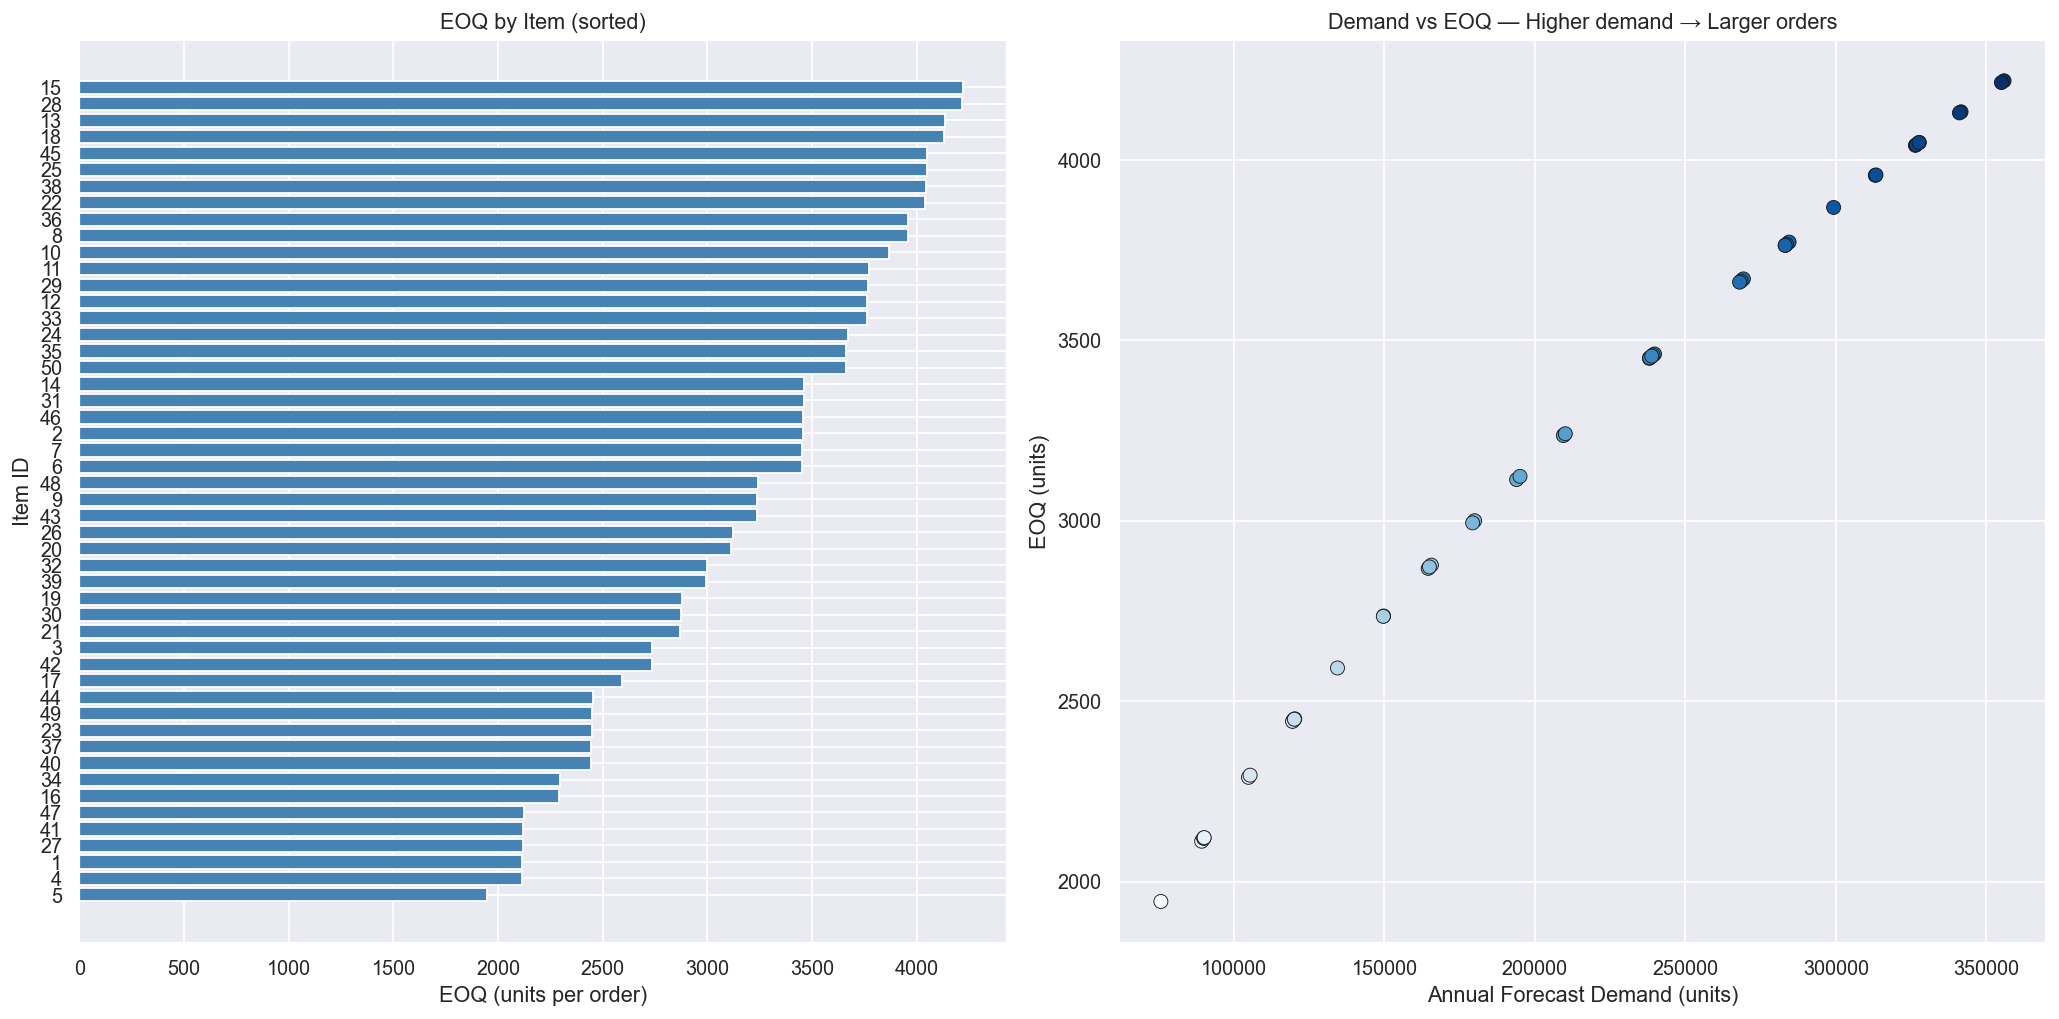

In [7]:
# Visualise EOQ across items 
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sorted_eoq = item_stats.sort_values('EOQ')
axes[0].barh(sorted_eoq['item'].astype(str), sorted_eoq['EOQ'], color='steelblue')
axes[0].set_xlabel('EOQ (units per order)')
axes[0].set_title('EOQ by Item (sorted)')
axes[0].set_ylabel('Item ID')

axes[1].scatter(item_stats['annual_forecast_demand'], item_stats['EOQ'],
                c=item_stats['EOQ'], cmap='Blues', edgecolors='k', linewidth=0.5, s=60)
axes[1].set_xlabel('Annual Forecast Demand (units)')
axes[1].set_ylabel('EOQ (units)')
axes[1].set_title('Demand vs EOQ — Higher demand → Larger orders')

plt.tight_layout()
plt.savefig('../plots/inventory_plots/EOQ_analysis.png', bbox_inches='tight')
plt.show()

---
## 5. Safety Stock (SS)

### The Formula

$$
\text{SS} = z \cdot \sigma_d \cdot \sqrt{L}
$$

| Symbol | Meaning | Source in this project |
|--------|---------|------------------------|
| **z** | Service level z-score | 1.645 for 95% service level |
| **σ_d** | Standard deviation of **daily** demand | `std_daily_demand` from XGBoost forecasts |
| **L** | Lead time in days | Business input: `LEAD_TIME_DAYS` |

### What it answers
> *"How much extra buffer stock should we keep to absorb unexpected demand spikes  
> during the lead time window, while achieving our target service level?"*

- Our XGBoost model has **MAPE ≈ 12.4%**, meaning predictions aren't perfect  
- During the lead time window, demand could spike beyond the forecast  
- Safety Stock = the insurance buffer sized to your risk tolerance (service level)

`How much extra inventory do I need during the waiting period after I place an order?`

In [8]:
def compute_safety_stock(z, sigma_daily_demand, lead_time_days):
    """Safety Stock using demand variability during lead time."""
    return z * sigma_daily_demand * np.sqrt(lead_time_days)

item_stats['safety_stock'] = compute_safety_stock(
    z                    = Z_SCORE,
    sigma_daily_demand   = item_stats['std_daily_demand'],
    lead_time_days       = LEAD_TIME_DAYS
).round(0).astype(int)

item_stats[['item','avg_daily_demand','std_daily_demand','cv','safety_stock']].head(10).round(2)

,item,avg_daily_demand,std_daily_demand,cv,safety_stock
0,1,245.309998,53.009998,0.22,231
1,2,654.539978,143.660004,0.22,625
2,3,410.190002,89.919998,0.22,391
3,4,244.470001,53.540001,0.22,233
4,5,207.320007,44.919998,0.22,196
5,6,652.210022,141.380005,0.22,615
6,7,652.450012,142.539993,0.22,620
7,8,857.960022,188.539993,0.22,821
8,9,574.500000,124.449997,0.22,542
9,10,820.010010,178.830002,0.22,778


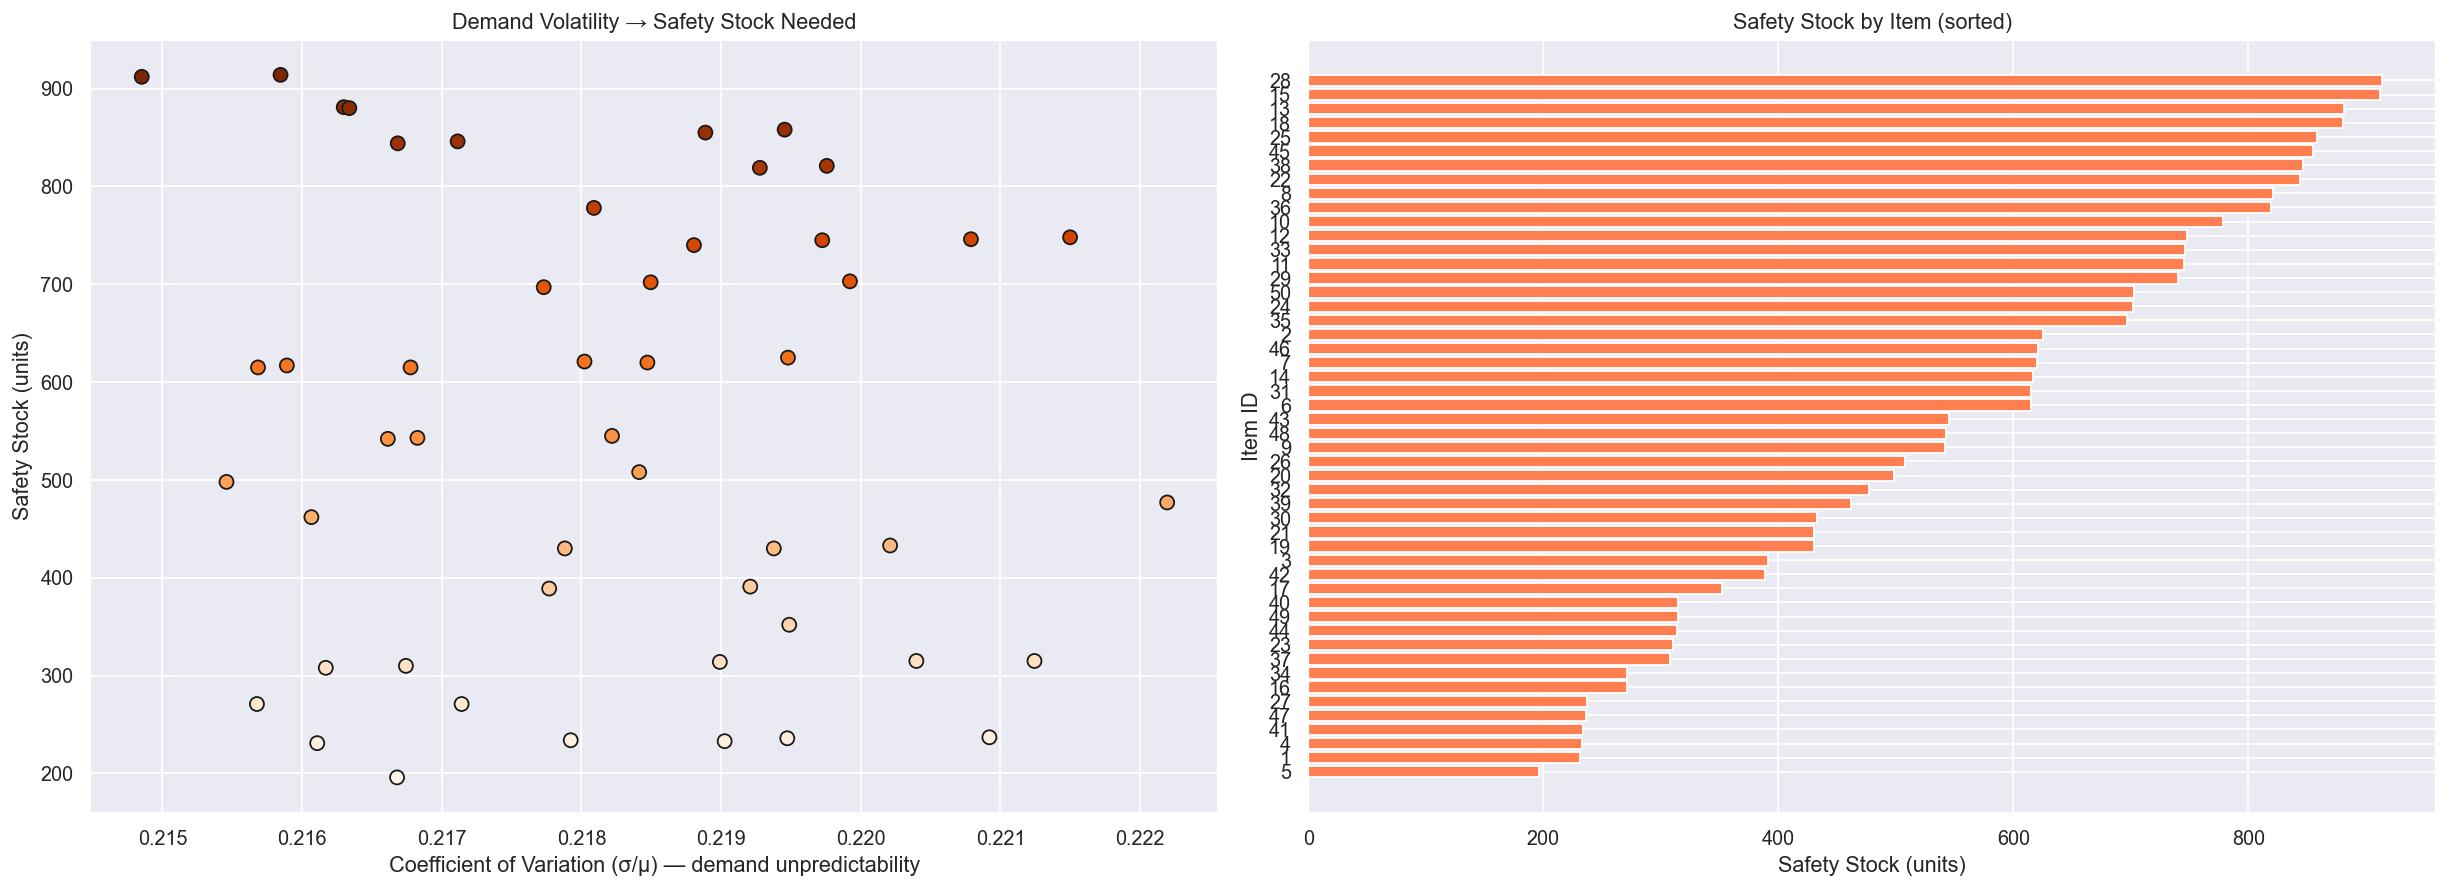

In [9]:
# ── How does demand variability drive Safety Stock? ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(19, 7))

axes[0].scatter(item_stats['cv'], item_stats['safety_stock'],
                c=item_stats['safety_stock'], cmap='Oranges', edgecolors='k', s=60)
axes[0].set_xlabel('Coefficient of Variation (σ/μ) — demand unpredictability')
axes[0].set_ylabel('Safety Stock (units)')
axes[0].set_title('Demand Volatility → Safety Stock Needed')

sorted_ss = item_stats.sort_values('safety_stock')
axes[1].barh(sorted_ss['item'].astype(str), sorted_ss['safety_stock'], color='coral')
axes[1].set_xlabel('Safety Stock (units)')
axes[1].set_title('Safety Stock by Item (sorted)')
axes[1].set_ylabel('Item ID')

plt.tight_layout()
plt.savefig('../plots/inventory_plots/SafetyStock_analysis.png', bbox_inches='tight')
plt.show()

---
## 6. Reorder Point (ROP)

### The Formula

$$
\text{ROP} = \underbrace{\bar{d} \cdot L}_{\text{Expected demand during lead time}} + \underbrace{\text{SS}}_{\text{Safety buffer}}
$$

| Symbol | Meaning | Source in this project |
|--------|---------|------------------------|
| **d̄** | Average daily demand (units/day) | XGBoost forecast mean per item |
| **L** | Lead time in days | Business input: `LEAD_TIME_DAYS` |
| **SS** | Safety Stock | Computed in section 5 |

### What it answers
> *"At what stock level should I trigger a new purchase order,  
> so that I don't run out before the next delivery arrives?"*

- The ROP accounts for **expected consumption** during the waiting period (lead time)  
- Plus **safety stock** to handle demand spikes above forecast

In [10]:
def compute_rop(avg_daily_demand, lead_time_days, safety_stock):
    """Reorder Point."""
    return (avg_daily_demand * lead_time_days) + safety_stock

item_stats['demand_during_lead_time'] = (
    item_stats['avg_daily_demand'] * LEAD_TIME_DAYS
).round(0).astype(int)

item_stats['ROP'] = compute_rop(
    avg_daily_demand = item_stats['avg_daily_demand'],
    lead_time_days   = LEAD_TIME_DAYS,
    safety_stock     = item_stats['safety_stock']
).round(0).astype(int)

item_stats[['item','avg_daily_demand','demand_during_lead_time','safety_stock','ROP']].head(10)

,item,avg_daily_demand,demand_during_lead_time,safety_stock,ROP
0,1,245.306000,1717,231,1948
1,2,654.538391,4582,625,5207
2,3,410.188171,2871,391,3262
3,4,244.469177,1711,233,1944
4,5,207.315887,1451,196,1647
5,6,652.206665,4565,615,5180
6,7,652.446899,4567,620,5187
7,8,857.961243,6006,821,6827
8,9,574.502930,4022,542,4564
9,10,820.005310,5740,778,6518


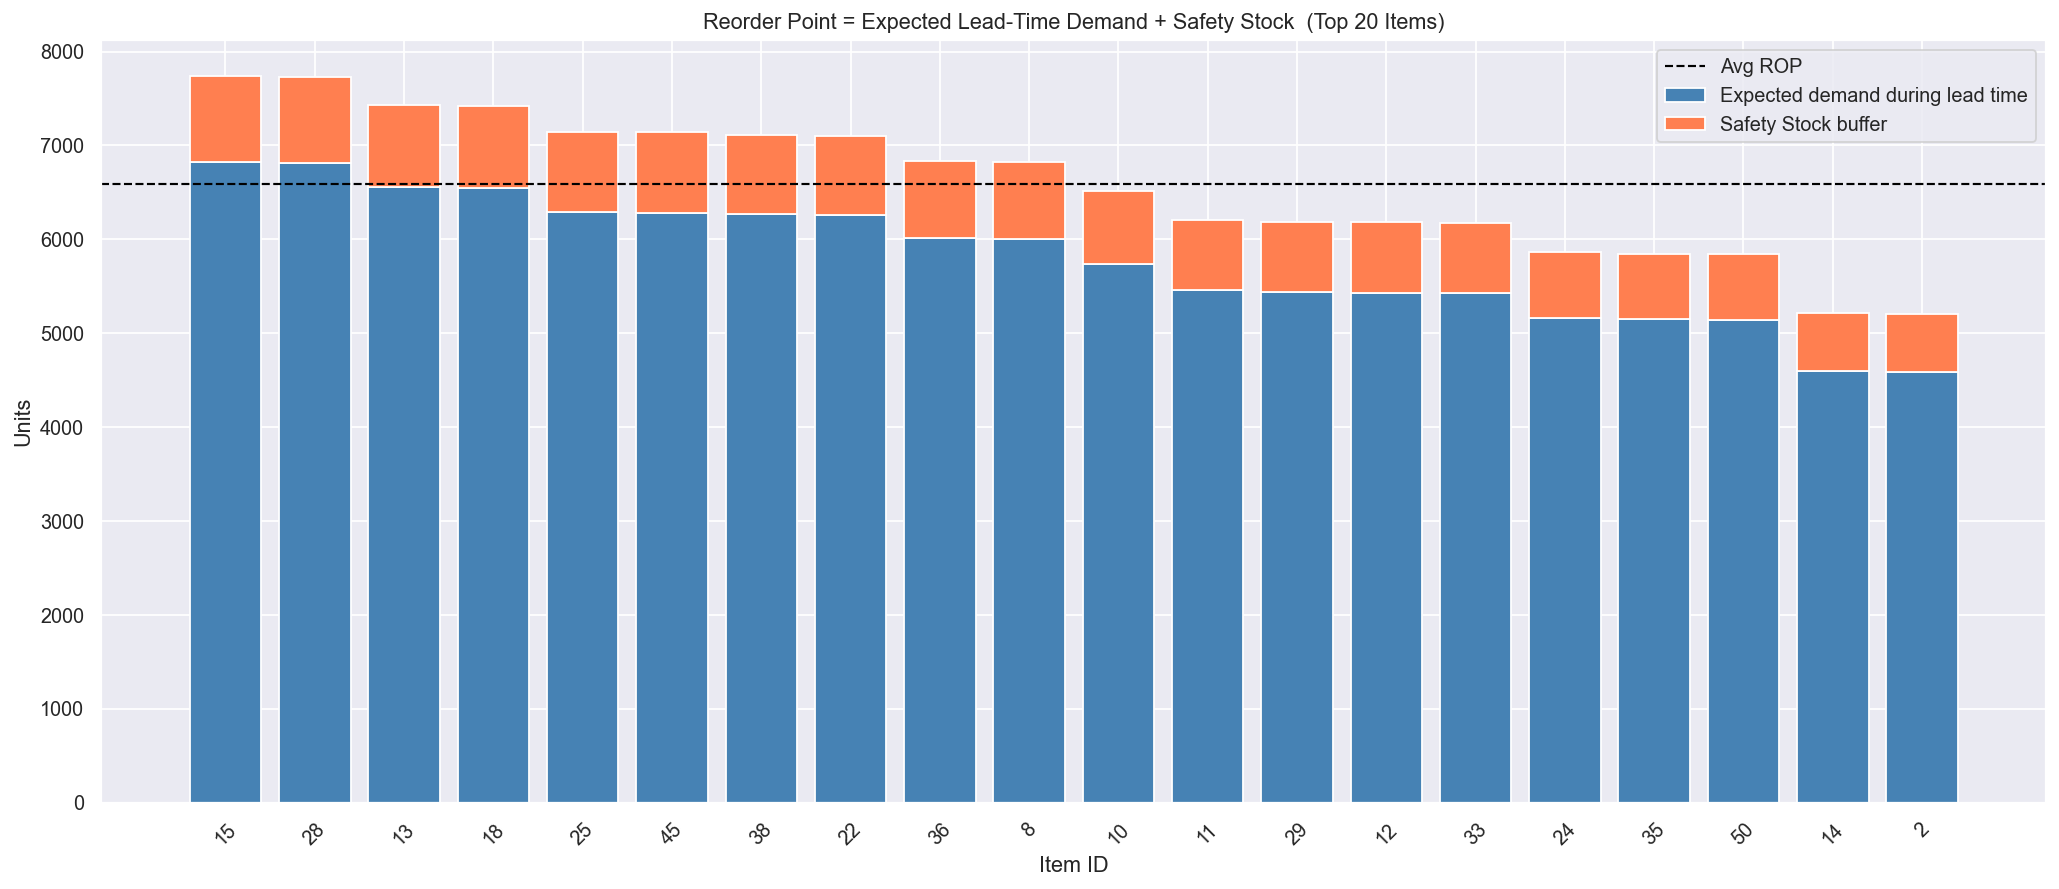

In [11]:
# ── ROP breakdown: expected demand vs safety buffer ──────────────────────────
top_items = item_stats.sort_values('ROP', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(top_items))
ax.bar(x, top_items['demand_during_lead_time'], label='Expected demand during lead time', color='steelblue')
ax.bar(x, top_items['safety_stock'], bottom=top_items['demand_during_lead_time'],
       label='Safety Stock buffer', color='coral')
ax.axhline(top_items['ROP'].mean(), color='black', linestyle='--', linewidth=1.2, label='Avg ROP')
ax.set_xticks(x)
ax.set_xticklabels(top_items['item'].astype(str), rotation=45)
ax.set_xlabel('Item ID')
ax.set_ylabel('Units')
ax.set_title('Reorder Point = Expected Lead-Time Demand + Safety Stock  (Top 20 Items)')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/inventory_plots/ROP_breakdown.png', bbox_inches='tight')
plt.show()

---
## 7. Final Inventory Policy Table

One row per item — the complete inventory policy derived from your XGBoost demand forecasts.

In [12]:
inventory_policy = item_stats[[
    'item',
    'annual_forecast_demand',
    'avg_daily_demand',
    'std_daily_demand',
    'cv',
    'EOQ',
    'orders_per_year',
    'safety_stock',
    'demand_during_lead_time',
    'ROP'
]].copy()

inventory_policy.columns = [
    'Item', 'Annual Demand (units)', 'Avg Daily Demand(d̄)',
    'Std Daily Demand(σ_d)', 'CV', 'EOQ (units/order)',
    'Orders / Year', 'Safety Stock', 'Lead-Time Demand', 'ROP'
]

print(f'Total Safety Stock (all items): {inventory_policy["Safety Stock"].sum():,} units')
print(f'Average EOQ                    : {inventory_policy["EOQ (units/order)"].mean():.0f} units')
print(f'Average ROP                    : {inventory_policy["ROP"].mean():.0f} units')
print()
inventory_policy.round(2)

Total Safety Stock (all items): 27,673 units
Average EOQ                    : 3189 units
Average ROP                    : 4635 units



,Item,Annual Demand (units),Avg Daily Demand(d̄),Std Daily Demand(σ_d),CV,EOQ (units/order),Orders / Year,Safety Stock,Lead-Time Demand,ROP
0,1,89536.687500,245.309998,53.009998,0.22,2116,42.3,231,1717,1948
1,2,238906.515625,654.539978,143.660004,0.22,3456,69.1,625,4582,5207
2,3,149718.687500,410.190002,89.919998,0.22,2736,54.7,391,2871,3262
3,4,89231.250000,244.470001,53.540001,0.22,2112,42.2,233,1711,1944
4,5,75670.296875,207.320007,44.919998,0.22,1945,38.9,196,1451,1647
5,6,238055.421875,652.210022,141.380005,0.22,3450,69.0,615,4565,5180
6,7,238143.125000,652.450012,142.539993,0.22,3451,69.0,620,4567,5187
7,8,313155.843750,857.960022,188.539993,0.22,3957,79.1,821,6006,6827
8,9,209693.578125,574.500000,124.449997,0.22,3238,64.8,542,4022,4564
9,10,299301.937500,820.010010,178.830002,0.22,3868,77.4,778,5740,6518


In [13]:
# Saving the policy table
inventory_policy.to_csv('../data/inventory_data/inventory_policy.csv', index=False)
print('Saved → ../data/inventory_data/inventory_policy.csv')

Saved → ../data/inventory_data/inventory_policy.csv
